# Whatsapp Group Chat Analysis Charts

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
#import data
data = pd.read_csv("data_sa.csv")

# Convert the 'date' column to datetime if not already
data['date'] = pd.to_datetime(data['date'], dayfirst=True, errors='coerce').dt.date

data.head()

,Unnamed: 0,date,time,sender,message,neg,neu,pos,compound
0,0,2020-08-27,12:16,IvanDB,ORGIEEEESSSSS,0.000,1.000,0.000,0.0000
1,1,2020-08-27,12:16,Laurent,Hello everyone. So i have added in Ivan. Might...,0.043,0.758,0.199,0.7876
2,2,2020-08-27,12:16,Laurent,So yay for orgies,0.000,0.448,0.552,0.5709
3,3,2020-08-27,12:16,Laurent,Thats how i sold it to Ivan. It worked i think,0.000,1.000,0.000,0.0000
4,4,2020-08-27,12:18,IvanDB,was it a lie? 😭,0.341,0.659,0.000,-0.4767


## Content Search

In [18]:
search_string = "science thursday" 

# filter rows where message contains "wednesday" (case-insensitive)
mask = data['message'].str.contains(search_string, case=False, na=False)
df_wed = data[mask]

# how many times mentioned
count_mentions = len(df_wed)

# first mention
first_mention = df_wed.sort_values(['date', 'time']).iloc[0] if count_mentions > 0 else None

# last mention
last_mention = df_wed.sort_values(['date', 'time']).iloc[-1] if count_mentions > 0 else None

# print results
print(f"{search_string} mentioned {count_mentions} times")

if first_mention is not None:
    print(f"\nFirst mention:")
    print(f"  Date: {first_mention['date']} Time: {first_mention['time']}")
    print(f"  Sender: {first_mention['sender']}")
    print(f"  Message: {first_mention['message']}")

if last_mention is not None:
    print(f"\nLast mention:")
    print(f"  Date: {last_mention['date']} Time: {last_mention['time']}")
    print(f"  Sender: {last_mention['sender']}")
    print(f"  Message: {last_mention['message']}")


science thursday mentioned 41 times

First mention:
  Date: 2025-02-12 Time: 13:20
  Sender: IvanDB
  Message: Guys, I think I want to do a Science Thursday with you where I just make one random statement related to science or math or anything counterintuitive and you have to discuss about it, even just telling me what you feel about it

Last mention:
  Date: 2025-07-24 Time: 18:53
  Sender: Laurent
  Message: And your lack of science thursday


## Sentiment Analysis

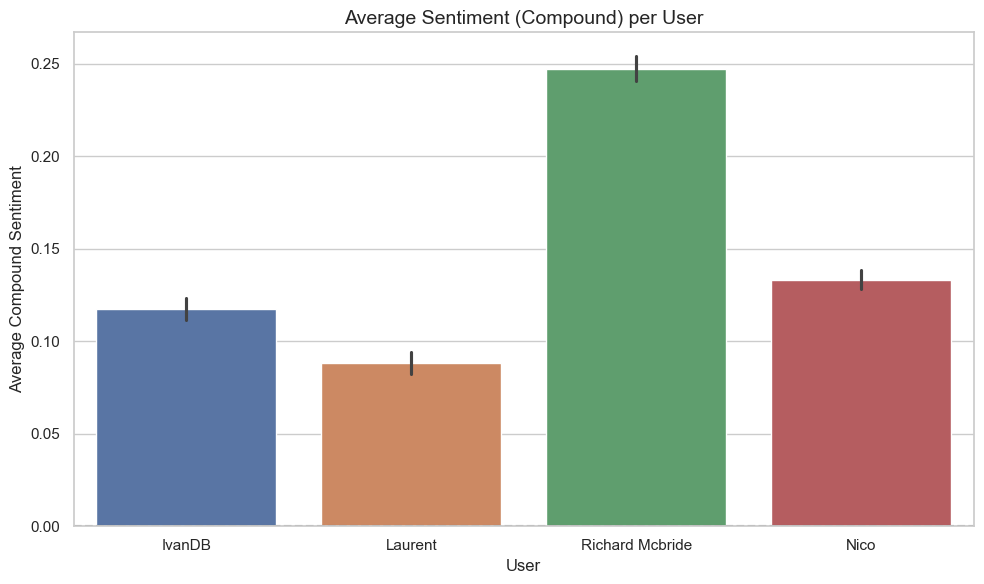

In [7]:
# Optional: set a nice theme
# sns.set(style="whitegrid")

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=data, x='sender', y='compound', hue='sender')

# Add title and labels
plt.title('Average Sentiment (Compound) per User', fontsize=14)
plt.xlabel('User')
plt.ylabel('Average Compound Sentiment')

# Add horizontal line at 0 (neutral)
plt.axhline(0, color='gray', linestyle='--')

plt.tight_layout()
plt.show()


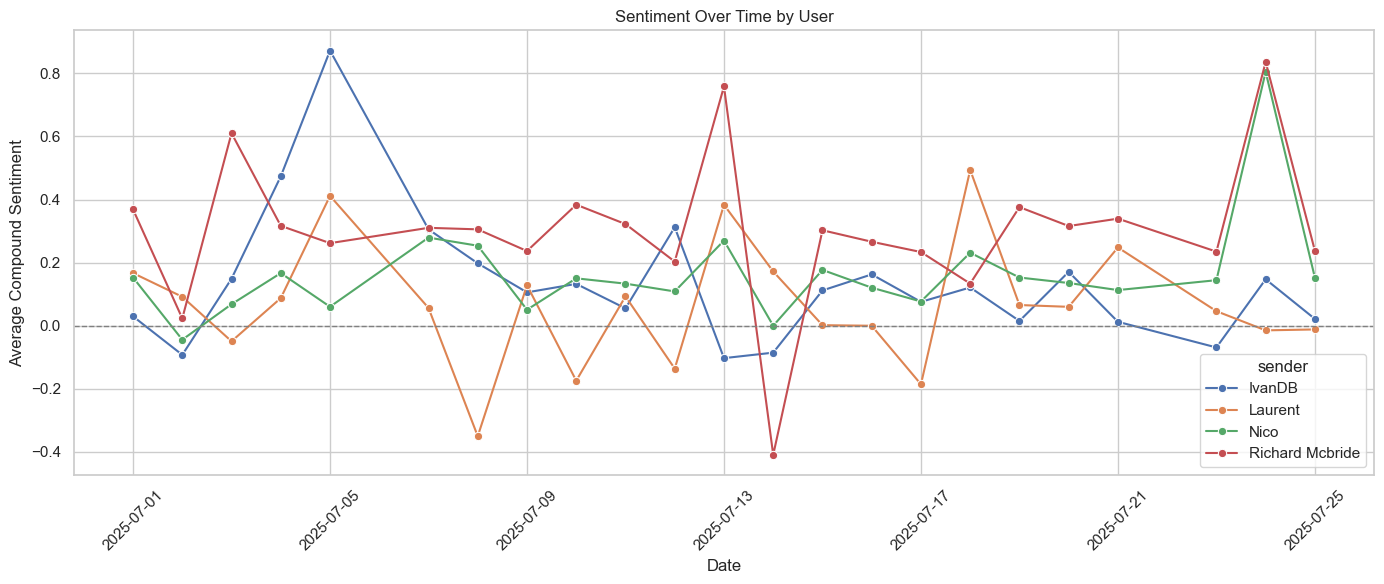

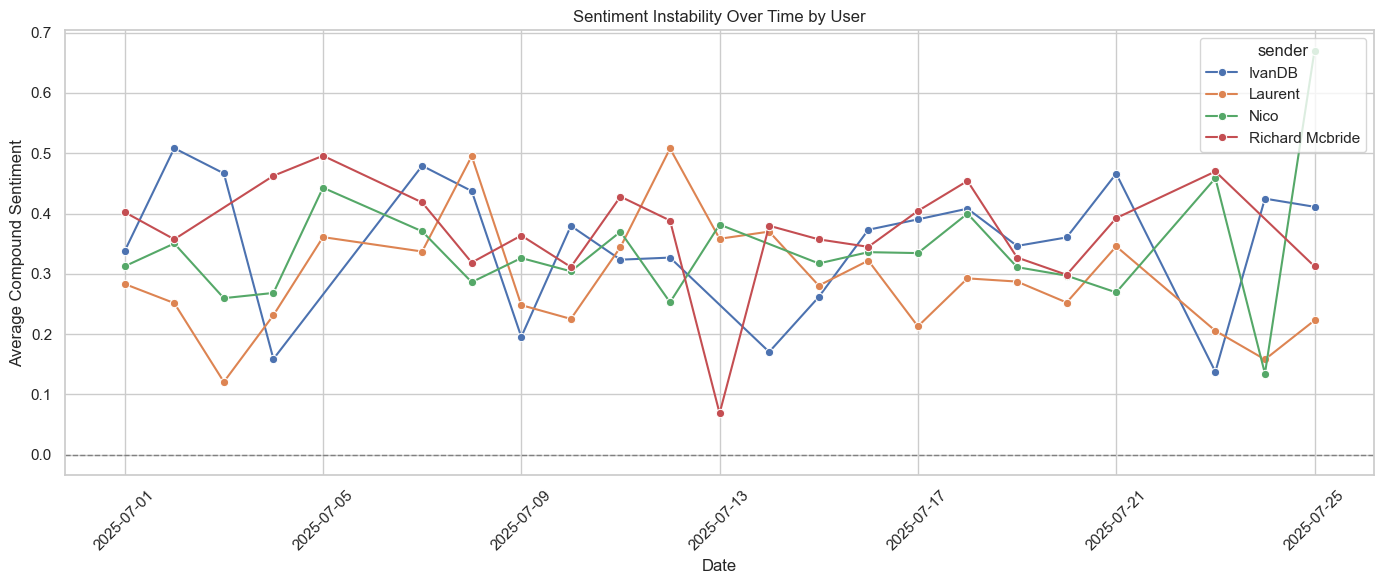

In [22]:
start_date = '2025-07-01'
end_date = '2025-07-25'

# Convert strings to datetime.date objects for comparison
start_date = pd.to_datetime(start_date).date()
end_date = pd.to_datetime(end_date).date()

# Group by sender and date (date as datetime.date)
daily_sentiment = data.groupby(['sender', data['date'].dt.date])['compound'].agg(['mean', 'std']).reset_index()
daily_sentiment.rename(columns={'mean': 'compound_mean', 'std': 'compound_std', 'date': 'date'}, inplace=True)


# Filter by date range (inclusive)
daily_sentiment = daily_sentiment[(daily_sentiment['date'] >= start_date) & (daily_sentiment['date'] <= end_date)]
# daily_sentiment = daily_sentiment[daily_sentiment['sender']=='IvanDB']


plt.figure(figsize=(14, 6))

# Plot each user's sentiment trend
sns.lineplot(data=daily_sentiment, x='date', y='compound_mean', hue='sender', marker='o')

plt.title('Sentiment Over Time by User')
plt.xlabel('Date')
plt.ylabel('Average Compound Sentiment')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)  # Neutral line
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

# Plot each user's sentiment trend
sns.lineplot(data=daily_sentiment, x='date', y='compound_std', hue='sender', marker='o')

plt.title('Sentiment Instability Over Time by User')
plt.xlabel('Date')
plt.ylabel('Average Compound Sentiment')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)  # Neutral line
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


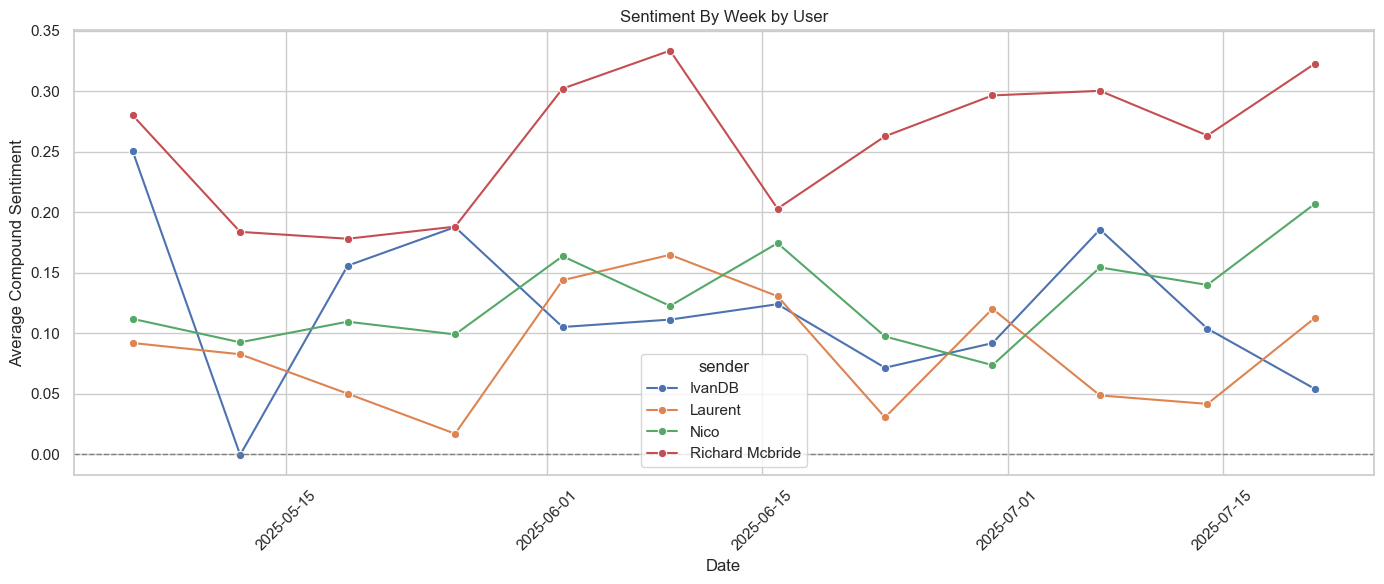

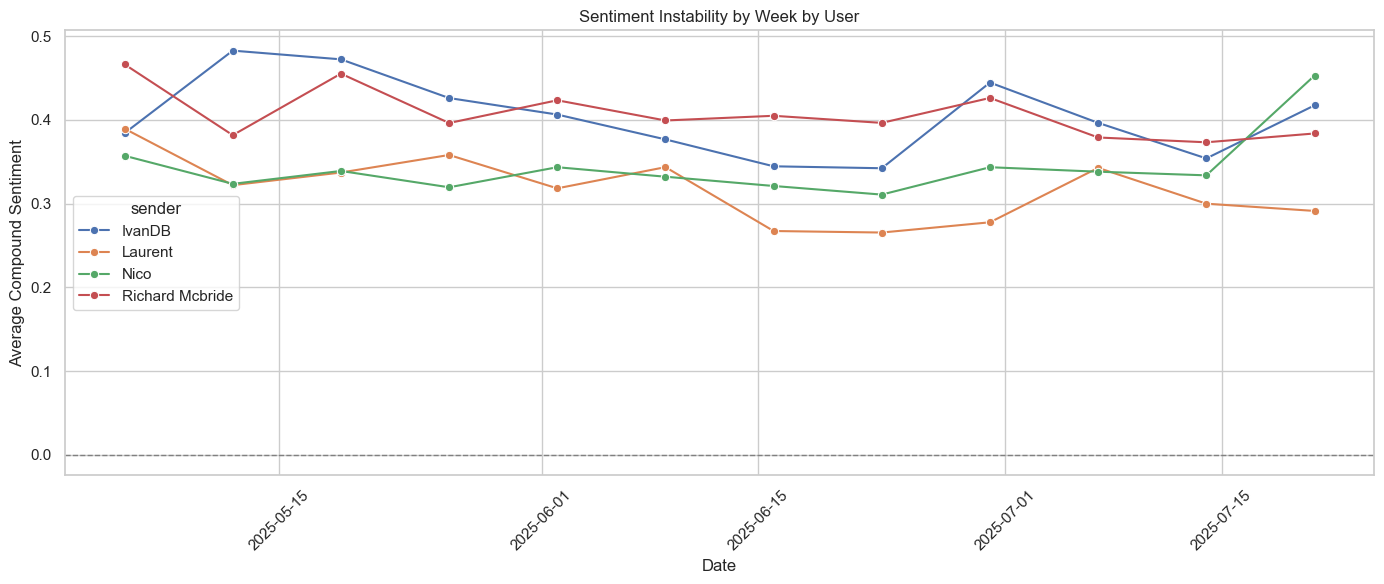

In [23]:
start_date = '2025-05-01'
end_date = '2025-07-25'

# Convert strings to datetime.date objects for comparison
start_date = pd.to_datetime(start_date)
end_date = pd.to_datetime(end_date)

data['week'] = data['date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_sentiment = data.groupby(['sender', 'week'])['compound'].agg(['mean', 'std']).reset_index()
weekly_sentiment.rename(columns={'mean': 'compound_mean', 'std': 'compound_std', 'date': 'date'}, inplace=True)

# Filter by date range (inclusive)
weekly_sentiment = weekly_sentiment[(weekly_sentiment['week'] >= start_date) & (weekly_sentiment['week'] <= end_date)]
# weekly_sentiment = weekly_sentiment[weekly_sentiment['sender']=='IvanDB']

plt.figure(figsize=(14, 6))

# Plot each user's sentiment trend
sns.lineplot(data=weekly_sentiment, x='week', y='compound_mean', hue='sender', marker='o')

plt.title('Sentiment By Week by User')
plt.xlabel('Date')
plt.ylabel('Average Compound Sentiment')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)  # Neutral line
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 6))

# Plot each user's sentiment trend
sns.lineplot(data=weekly_sentiment, x='week', y='compound_std', hue='sender', marker='o')

plt.title('Sentiment Instability by Week by User')
plt.xlabel('Date')
plt.ylabel('Average Compound Sentiment')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)  # Neutral line
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Emotions Analysis

In [103]:
data_with_emotions = pd.read_csv("data_with_emotions.csv")
# data_with_emotions.head()
# Group by sender, take mean of each emotion column

emotion_cols = ['anger', 'disgust','fear','joy','sadness','surprise'] #removed 'neutral'
# emotion_cols = emotion_df.columns.tolist()
avg_emotions_by_user = data_with_emotions.groupby('sender')[emotion_cols].mean().reset_index()

# # Melt for easier seaborn plotting
avg_emotions_melted = avg_emotions_by_user.melt(id_vars='sender', var_name='emotion', value_name='avg_score')
# avg_emotions_melted = avg_emotions_melted[avg_emotions_melted['sender']=='IvanDB']

# avg_emotions_by_user


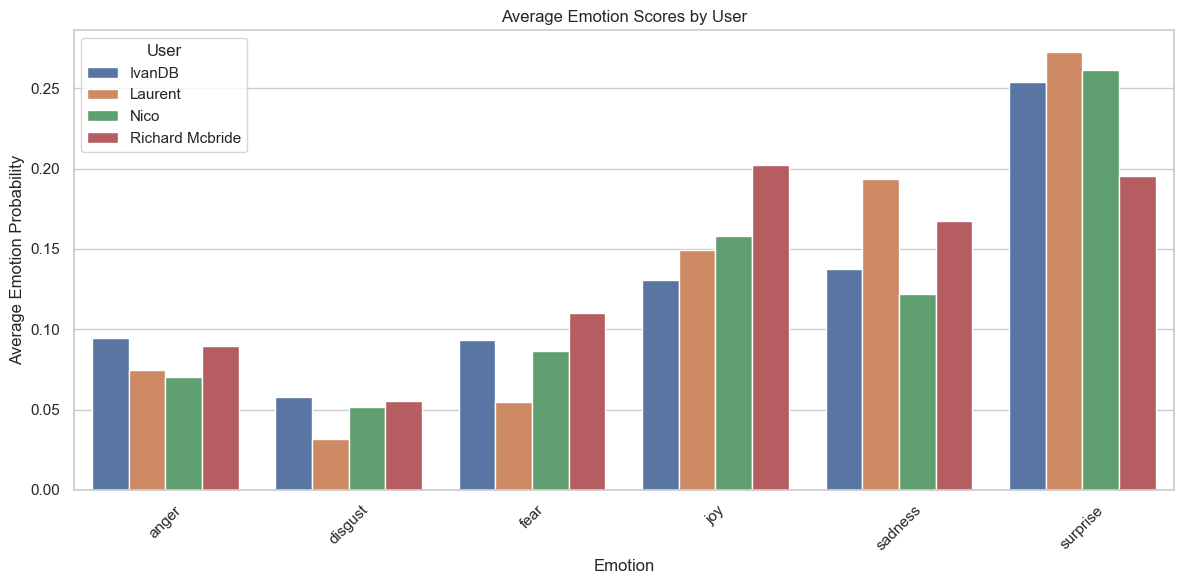

In [104]:
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_emotions_melted, x='emotion', y='avg_score', hue='sender')
plt.title('Average Emotion Scores by User')
plt.ylabel('Average Emotion Probability')
plt.xlabel('Emotion')
plt.xticks(rotation=45)
plt.legend(title='User')
plt.tight_layout()
plt.show()


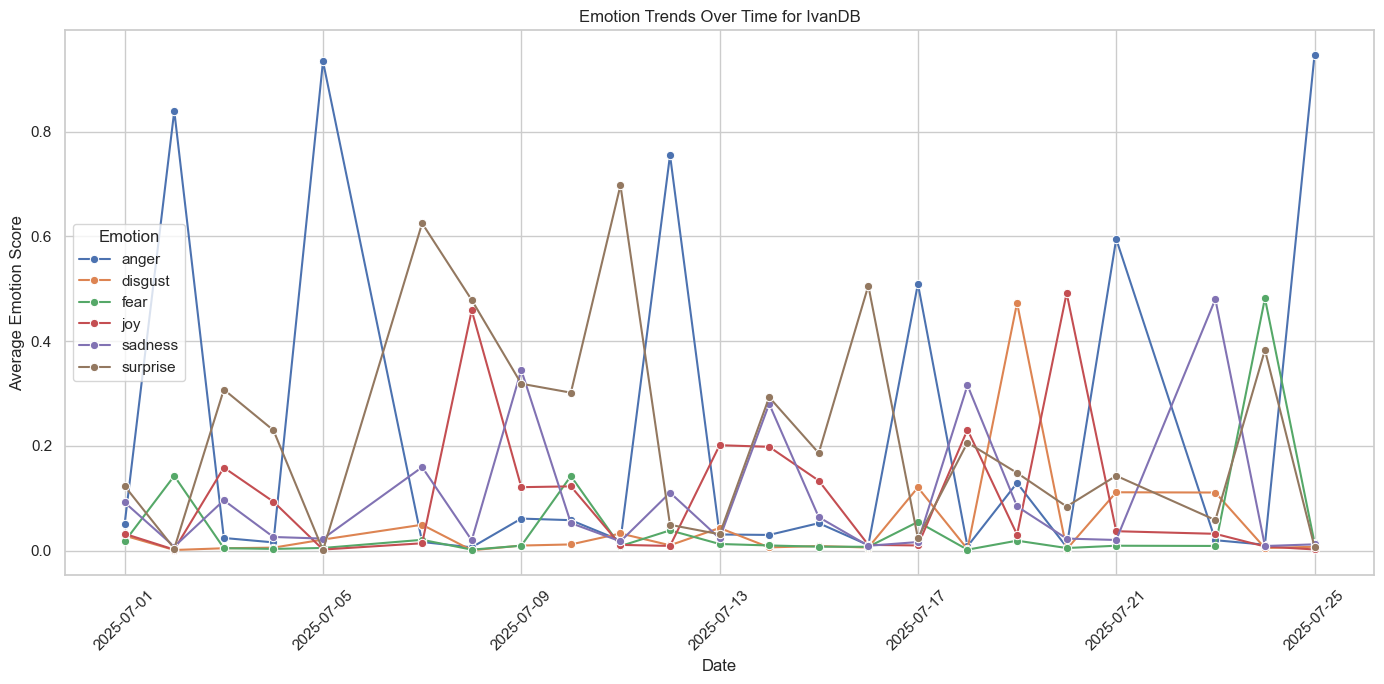

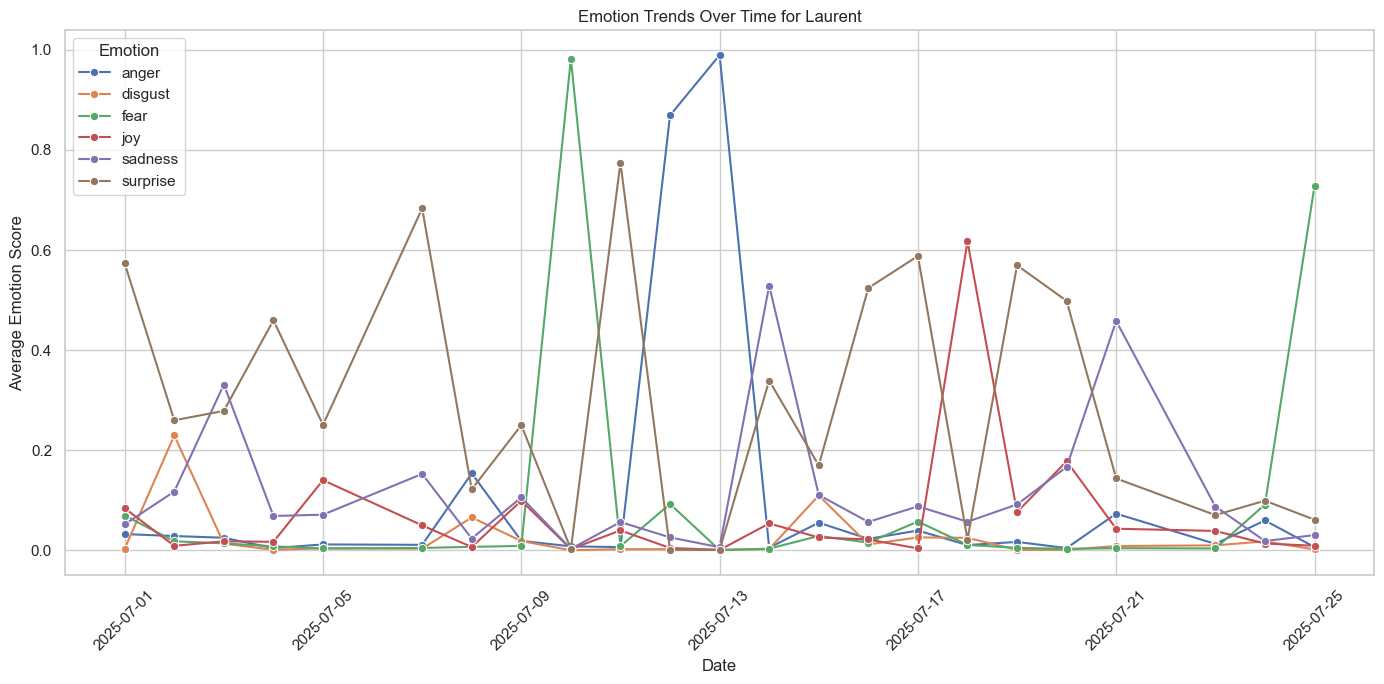

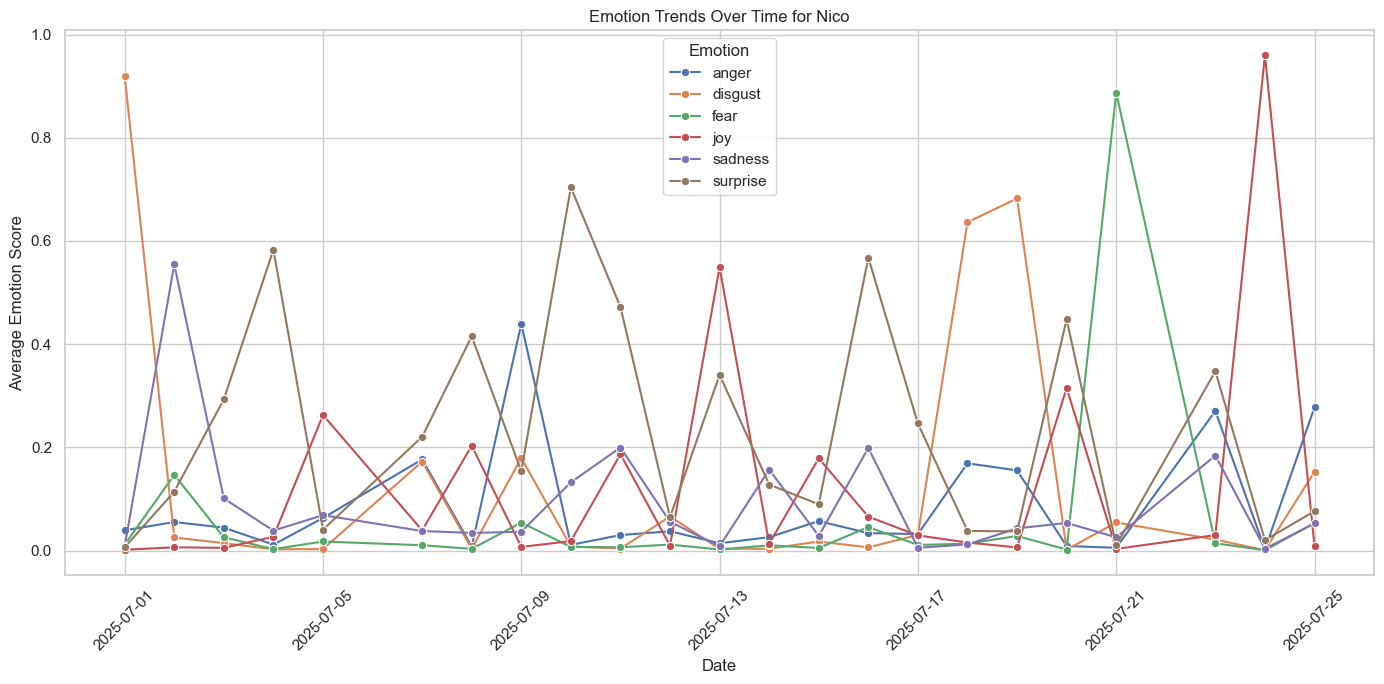

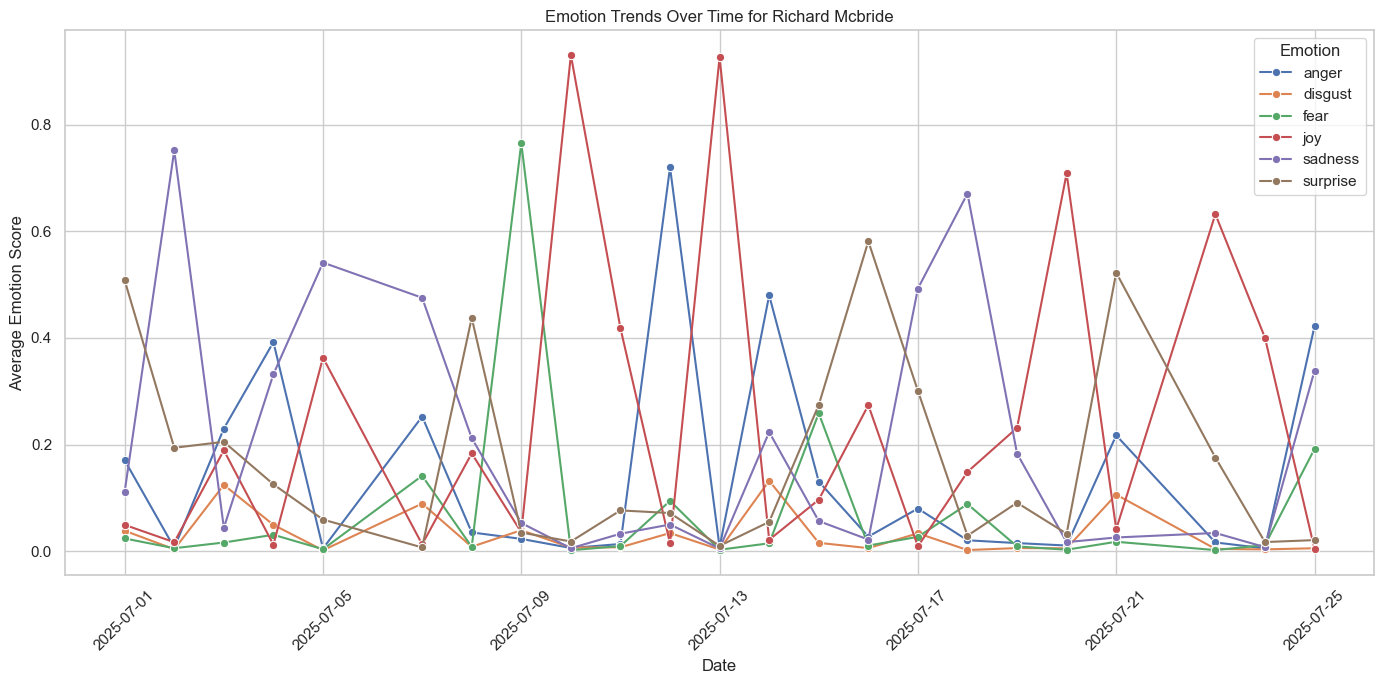

In [114]:
start_date = '2025-07-01'
end_date = '2025-07-25'

# Convert strings to datetime.date objects for comparison
start_date = pd.to_datetime(start_date).date()
end_date = pd.to_datetime(end_date).date()

# Add a date-only column if you don't have it
data_with_emotions['date_only'] = pd.to_datetime(data_with_emotions['date']).dt.date

# Pick one user
# user = 'IvanDB'
for user in data_with_emotions.sender.unique():
    user_data = data_with_emotions[data_with_emotions['sender'] == user]

    # Group by date and take average emotion scores
    daily_emotions = user_data.groupby('date_only')[emotion_cols].mean().reset_index()

    # Filter by date range (inclusive)
    daily_emotions = daily_emotions[(daily_emotions['date_only'] >= start_date) & (daily_emotions['date_only'] <= end_date)]

    # Plot emotions over time
    plt.figure(figsize=(14, 7))
    for emotion in emotion_cols:
        sns.lineplot(data=daily_emotions, x='date_only', y=emotion, label=emotion, marker='o')

    plt.title(f'Emotion Trends Over Time for {user}')
    plt.xlabel('Date')
    plt.ylabel('Average Emotion Score')
    plt.xticks(rotation=45)
    plt.legend(title='Emotion')
    plt.tight_layout()
    plt.show()


In [107]:
user_data[user_data['anger']>0.9]['chunk'].to_list()

['Nerdy guys, I need advice. I am in a "graphic novel" phase of my life. In the last month, I read Watchmen and Maus and the first book of the sandman and ordered the first book of Saga. BUT, I realised that I don\'t want to start a looong comic book series with 759758 comics etc, I would prefer a short good graphic novel that is from 1 to 5 books topss... any suggestions? maybe I found one... do you know this? ... https://imagecomics.com/comics/releases/chronicles-of-hate-collected-edition-of-book-1-2-tp Ok, another question (sorry, today I am chatty). I am watching "Come dine with me". Are those people in the show particularly stupid or is it a fair representation of English people? Ok, I prefer to think that they chose twats for the show There was an allegedly "Italian" guy that tried to make pasta and he messed up, I was furious FURIOUS!!! It cannot be representative, but if it is, that would explain Brexit It was from scratch and his father was very disappointed of him, so he woul

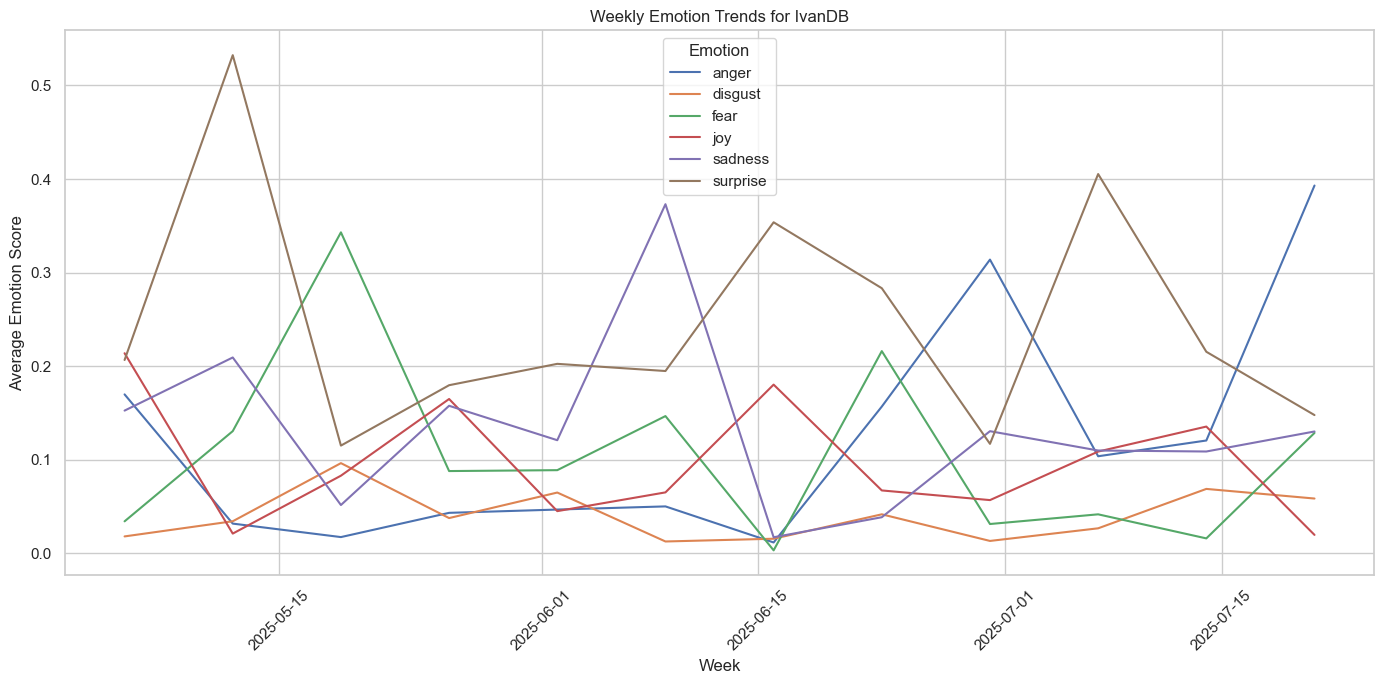

In [108]:
# Define your start and end dates
start_date = pd.to_datetime('2025-05-01')
end_date = pd.to_datetime('2025-07-25')

# Ensure 'date' column is datetime
data_with_emotions['date'] = pd.to_datetime(data_with_emotions['date'])

# Create a 'week' column representing the start of the week
data_with_emotions['week'] = data_with_emotions['date'].dt.to_period('W').apply(lambda r: r.start_time)

# Pick one user
user = 'IvanDB'
user_data = data_with_emotions[data_with_emotions['sender'] == user]

# Filter by date range
user_data = user_data[(user_data['week'] >= start_date) & (user_data['week'] <= end_date)]

# Group by week and average emotion scores
weekly_emotions = user_data.groupby('week')[emotion_cols].mean().reset_index()

# Plot emotions over time
plt.figure(figsize=(14, 7))
for emotion in emotion_cols:
    sns.lineplot(data=weekly_emotions, x='week', y=emotion, label=emotion)

plt.title(f'Weekly Emotion Trends for {user}')
plt.xlabel('Week')
plt.ylabel('Average Emotion Score')
plt.xticks(rotation=45)
plt.legend(title='Emotion')
plt.tight_layout()
plt.show()


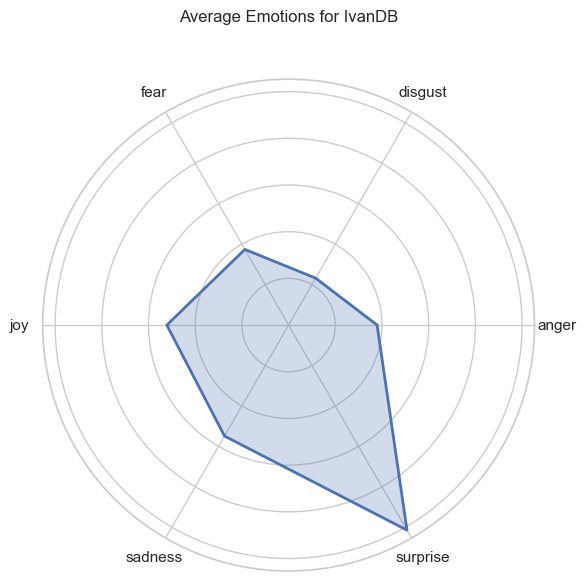

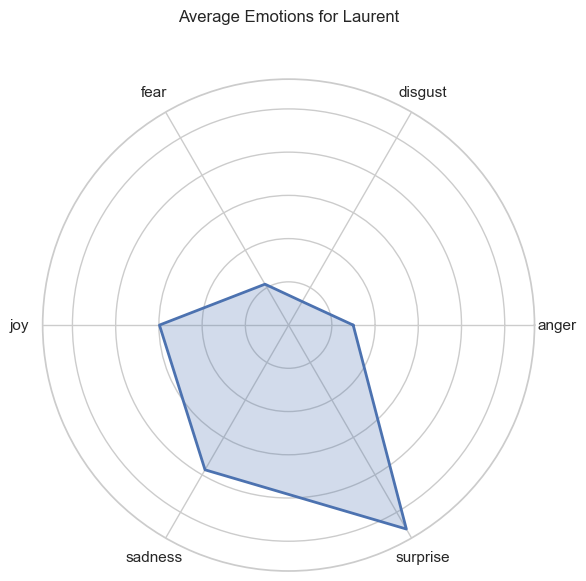

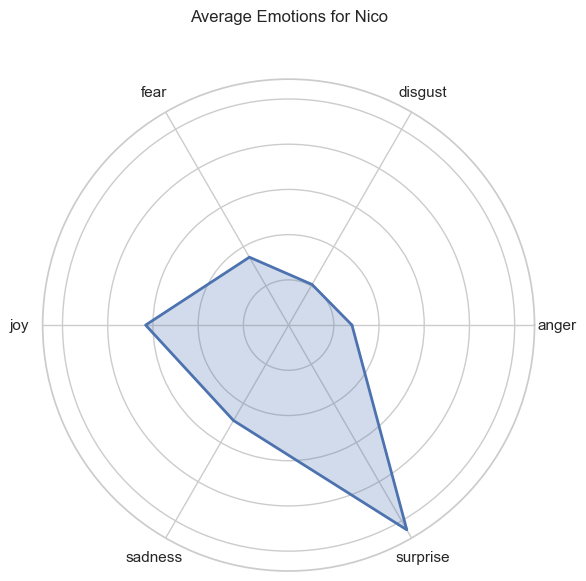

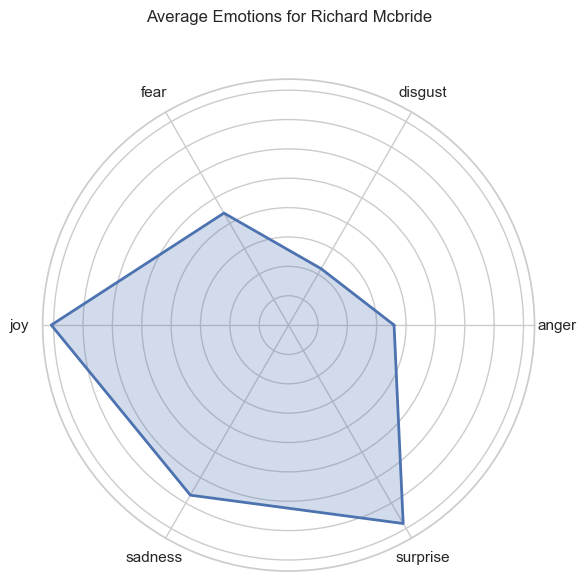

In [111]:
avg_emotions = data_with_emotions.groupby('sender')[emotion_cols].mean().reset_index()

# Create radar chart per user
def plot_radar_chart(row, emotion_cols):
    user = row['sender']
    values = row[emotion_cols].values.tolist()
    
    # Close the loop for radar
    values += values[:1]
    angles = np.linspace(0, 2 * np.pi, len(emotion_cols), endpoint=False).tolist()
    angles += angles[:1]

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(emotion_cols)
    ax.set_title(f'Average Emotions for {user}', y=1.1)
    ax.set_yticklabels([])  # Hide radial grid labels
    plt.tight_layout()
    plt.show()

# Plot for each user
for i, row in avg_emotions.iterrows():
    # if row['sender']=='IvanDB':
    #     plot_radar_chart(row, emotion_cols)
    plot_radar_chart(row, emotion_cols)


## Mental Health Detection

In [69]:
data_mental = pd.read_csv('data_mental.csv')
data_mental.head()

,sender,date,chunk,messages_in_chunk,token_count,mental_scores,LABEL_0,LABEL_1
0,IvanDB,2020-08-27,"ORGIEEEESSSSS was it a lie? 😭 let's say ""frien...",10,450,"[{'label': 'LABEL_0', 'score': 0.4783481359481...",0.478348,0.521652
1,IvanDB,2020-08-27,"yes, that's life. Nothing is black and white, ...",19,496,"[{'label': 'LABEL_0', 'score': 0.5119376778602...",0.511938,0.488062
2,IvanDB,2020-08-27,Can we replace 💨 with 🌬️? Or I want 💦 instead ...,5,152,"[{'label': 'LABEL_0', 'score': 0.4853875041007...",0.485388,0.514612
3,IvanDB,2020-08-28,Good luck with the big conversation!! by the w...,17,354,"[{'label': 'LABEL_0', 'score': 0.4786583185195...",0.478658,0.521342
4,IvanDB,2020-08-30,"Hi guys, happy sunday. Soooo, we are on the tr...",7,269,"[{'label': 'LABEL_0', 'score': 0.5045533180236...",0.504553,0.495447


In [76]:
data_mental.sender.unique()

array(['IvanDB', 'Laurent', 'Nico', 'Richard Mcbride'], dtype=object)

C:\Users\ivand\AppData\Local\Temp\ipykernel_16804\748041463.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Stress')


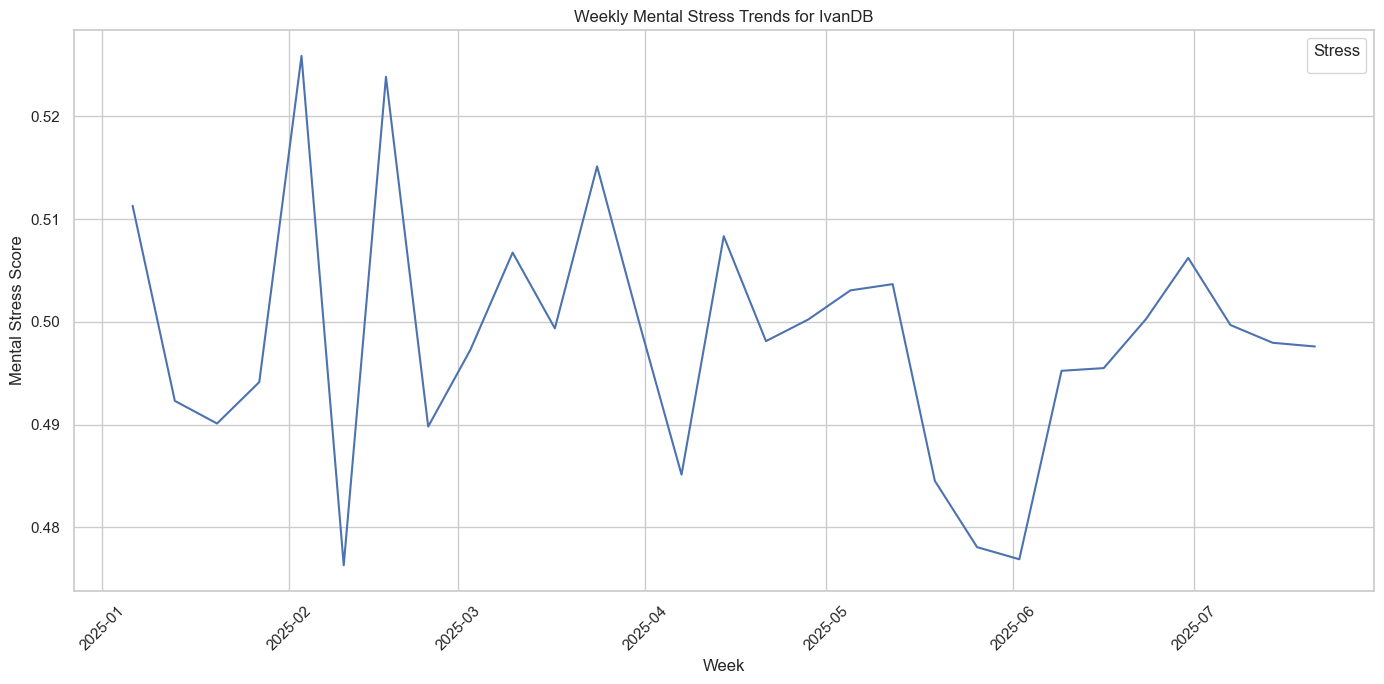

In [ ]:
# Define your start and end dates
start_date = pd.to_datetime('2025-01-01')
end_date = pd.to_datetime('2025-07-25')

# Ensure 'date' column is datetime
data_mental['date'] = pd.to_datetime(data_mental['date'])

# Create a 'week' column representing the start of the week
data_mental['week'] = data_mental['date'].dt.to_period('W').apply(lambda r: r.start_time)

# # Pick one user
user = 'IvanDB'
user_data = data_mental[data_mental['sender'] == user]
# user_data=data_mental.copy()

# Filter by date range
user_data = user_data[(user_data['week'] >= start_date) & (user_data['week'] <= end_date)]

# Group by week and average emotion scores
weekly_mental = user_data.groupby('week')['LABEL_1'].mean().reset_index()

# Plot emotions over time
plt.figure(figsize=(14, 7))
sns.lineplot(data=weekly_mental, x='week', y='LABEL_1')
plt.title(f'Weekly Mental Stress Trends for {user}')
plt.xlabel('Week')
plt.ylabel('Mental Stress Score')
plt.xticks(rotation=45)
plt.legend(title='Stress')
plt.tight_layout()
plt.show()


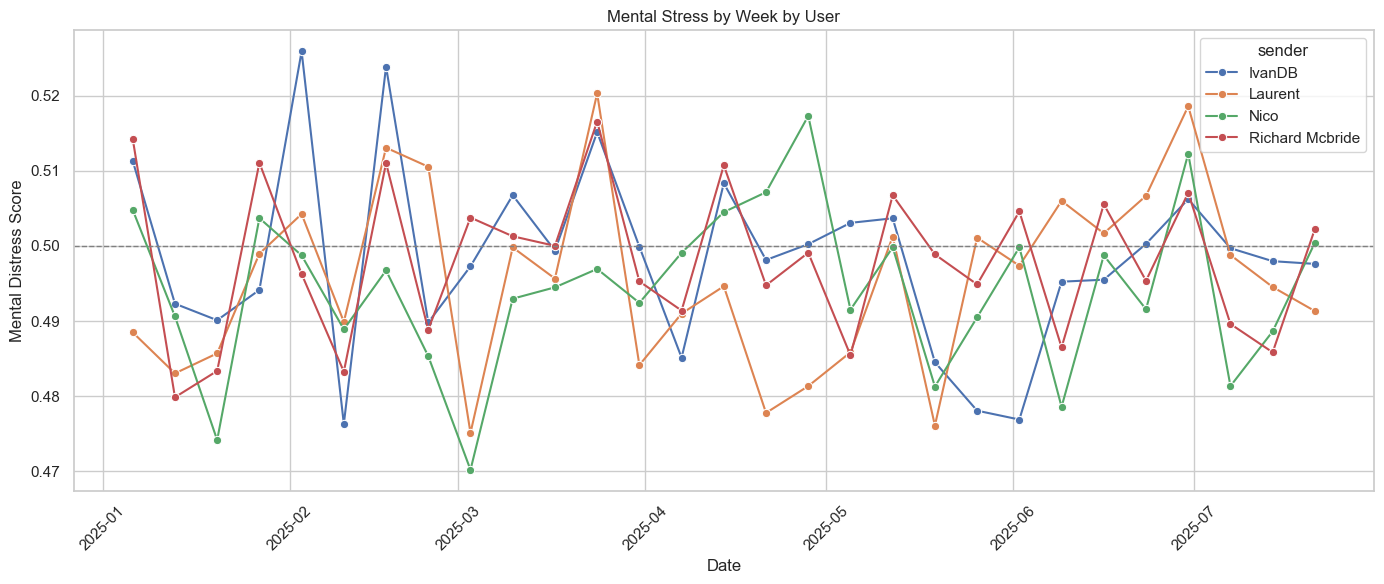

In [86]:
# Define your start and end dates
start_date = pd.to_datetime('2025-01-01')
end_date = pd.to_datetime('2025-07-25')

# Ensure 'date' column is datetime
data_mental['date'] = pd.to_datetime(data_mental['date'])

# Create a 'week' column representing the start of the week
data_mental['week'] = data_mental['date'].dt.to_period('W').apply(lambda r: r.start_time)

# Filter by date range
data_mental = data_mental[(data_mental['week'] >= start_date) & (data_mental['week'] <= end_date)]

# Group by week and average emotion scores
weekly_mental = data_mental.groupby(['week', 'sender'])['LABEL_1'].mean().reset_index()


plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_mental, x='week', y='LABEL_1', hue='sender', marker='o')
plt.title('Mental Stress by Week by User')
plt.xlabel('Date')
plt.ylabel('Mental Distress Score')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)  # Neutral line
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

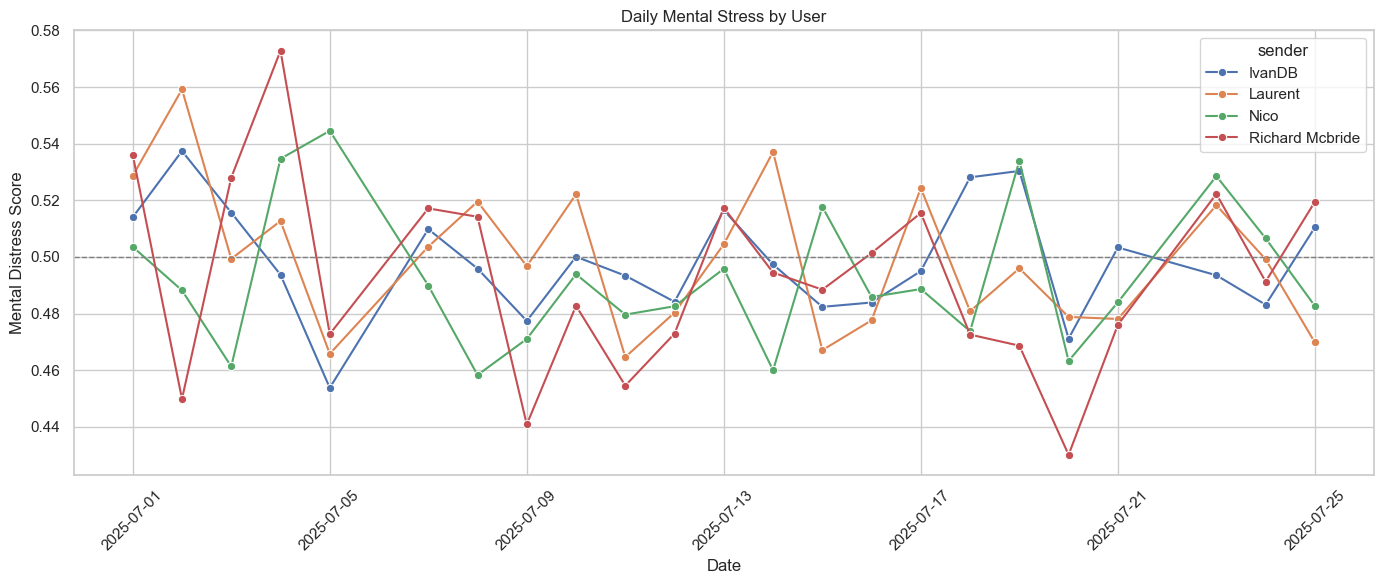

In [95]:
start_date = '2025-07-01'
end_date = '2025-07-25'

# Convert strings to datetime.date objects for comparison
start_date = pd.to_datetime(start_date).date()
end_date = pd.to_datetime(end_date).date()

# Group by sender and date (date as datetime.date)
daily_stress = data_mental.groupby(['sender', data_mental['date'].dt.date])['LABEL_1'].agg(['mean']).reset_index()


# Filter by date range (inclusive)
daily_stress = daily_stress[(daily_stress['date'] >= start_date) & (daily_stress['date'] <= end_date)]


plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_stress, x='date', y='mean', hue='sender', marker='o')
plt.title('Daily Mental Stress by User')
plt.xlabel('Date')
plt.ylabel('Mental Distress Score')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)  # Neutral line
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [94]:
daily_stress

,sender,date,mean
155,IvanDB,2025-07-01,0.514030
156,IvanDB,2025-07-02,0.537409
157,IvanDB,2025-07-03,0.515659
158,IvanDB,2025-07-04,0.493716
159,IvanDB,2025-07-05,0.453768
...,...,...,...
705,Richard Mcbride,2025-07-20,0.430101
706,Richard Mcbride,2025-07-21,0.476016
707,Richard Mcbride,2025-07-23,0.522237
708,Richard Mcbride,2025-07-24,0.491274


In [97]:
from transformers import pipeline

# classifier = pipeline("text-classification", model="bhadresh-savani/distilbert-base-uncased-emotion", return_all_scores=True)
classifier = pipeline("text-classification", model="Xuhui/mental-health-bert", return_all_scores=True)

print(classifier("I feel like everything is falling apart."))


OSError: Xuhui/mental-health-bert is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

In [ ]:
# #This model fine-tunes Bio_ClinicalBERT to predict mental health diagnoses from patient statements. It can classify text into 5 categories:

# Anxiety
# Depression
# Suicidal
# Stress
# Normal


from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("ethandavey/mental-health-diagnosis-bert")
model = AutoModelForSequenceClassification.from_pretrained("ethandavey/mental-health-diagnosis-bert")

# Prepare text
text = "I've been feeling very anxious and worried all the time."
inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)

# Make prediction
with torch.no_grad():
    outputs = model(**inputs)
    probabilities = F.softmax(outputs.logits, dim=1)

# Map prediction to label
label_mapping = {0: "Anxiety", 1: "Normal", 2: "Depression", 3: "Suicidal", 4: "Stress"}
predicted_class = torch.argmax(probabilities, dim=1).item()
prediction = label_mapping[predicted_class]
confidence = probabilities[0][predicted_class].item()

print(f"Prediction: {prediction}, Confidence: {confidence:.2f}")


c:\Users\ivand\anaconda3\envs\whatsapp_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ivand\.cache\huggingface\hub\models--ethandavey--mental-health-diagnosis-bert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\ivand\anaconda3\envs\whatsapp_env\Lib\site-packages\torch\nn\modules\module.p

Prediction: Anxiety, Confidence: 0.97


In [101]:
probabilities

tensor([[9.7172e-01, 1.3009e-02, 2.0255e-03, 9.3382e-04, 1.2311e-02]])

In [102]:
outputs

SequenceClassifierOutput(loss=None, logits=tensor([[ 4.4961,  0.1827, -1.6771, -2.4514,  0.1276]]), hidden_states=None, attentions=None)